**Setup. Install and import libraries**

In [1]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 25.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV, Lasso, ElasticNet
from sklearn.svm import SVR

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import joblib
import os

# Reproducibility setting
RANDOM_STATE = 42

# Display setting
pd.set_option("display.max_columns", 100)

print("Setup complete.")

Setup complete.


**Step 1. Load QSAR dataset**

In [3]:
df_qsar = pd.read_csv("DPP4_QSAR_dataset_parent_cleaned_locked.csv")

print("Dataset shape:", df_qsar.shape)
print("Columns:")
print(df_qsar.columns.tolist())

df_qsar.head()

Dataset shape: (3666, 25)
Columns:
['parent_smiles', 'molecule_chembl_id', 'pref_name', 'canonical_smiles_examples', 'n_records', 'IC50_nM_median', 'IC50_nM_min', 'IC50_nM_max', 'pIC50_median', 'pIC50_min', 'pIC50_max', 'pIC50_std', 'pchembl_median', 'assay_type', 'assay_chembl_id', 'document_chembl_id', 'mw_freebase', 'alogp', 'hba', 'hbd', 'psa', 'rtb', 'num_ro5_violations', 'pIC50_range', 'activity_class']


,parent_smiles,molecule_chembl_id,pref_name,canonical_smiles_examples,n_records,IC50_nM_median,IC50_nM_min,IC50_nM_max,pIC50_median,pIC50_min,pIC50_max,pIC50_std,pchembl_median,assay_type,assay_chembl_id,document_chembl_id,mw_freebase,alogp,hba,hbd,psa,rtb,num_ro5_violations,pIC50_range,activity_class
0,Brc1nc2n(n1)CC(c1cc3ccccc3o1)=NN2,CHEMBL4246951,NaN,Brc1nc2n(n1)CC(c1cc3ccccc3o1)=NN2,1,28050.00,28050.00,28050.00,4.552067,4.552067,4.552067,0.0,4.55,B,CHEMBL4232372,CHEMBL4229387,318.13,2.62,6.0,1.0,68.24,1.0,0.0,0.0,Low
1,C#CCN(CC#N)C(=O)[C@@H]1C[C@H](C(=O)N(C)C)[C@H]...,CHEMBL260701,NaN,C#CCN(CC#N)C(=O)[C@@H]1C[C@H](C(=O)N(C)C)[C@H]...,1,60.00,60.00,60.00,7.221849,7.221849,7.221849,0.0,7.22,B,CHEMBL939125,CHEMBL1143890,276.34,-0.57,4.0,1.0,76.44,4.0,0.0,0.0,High
2,C#CCn1c(=O)n(C)c(=O)c2c1nc(N1CCCC(N)C1)n2Cc1cc...,CHEMBL3913618,NaN,C#CCn1c(=O)n(C)c(=O)c2c1nc(N1CCCC(N)C1)n2Cc1cc...,1,16.00,16.00,16.00,7.795880,7.795880,7.795880,0.0,7.80,B,CHEMBL3888356,CHEMBL3886676,417.47,0.38,9.0,1.0,114.87,4.0,0.0,0.0,High
3,C#CCn1c(N2CCC[C@H](N)C2)nc2c1c(=O)n(Cc1nc(C)c3...,CHEMBL5277490,NaN,C#CCn1c(N2CCC[C@H](N)C2)nc2c1c(=O)n(Cc1nc(C)c3...,1,1.33,1.33,1.33,8.876148,8.876148,8.876148,0.0,8.88,B,CHEMBL5247172,CHEMBL5244277,458.53,0.76,10.0,1.0,116.86,4.0,0.0,0.0,High
4,C#Cc1cnc(N2CCC[C@@H](N)C2)n(Cc2ccccc2C#N)c1=O,CHEMBL1650422,NaN,C#Cc1cnc(N2CCC[C@@H](N)C2)n(Cc2ccccc2C#N)c1=O,1,5.00,5.00,5.00,8.301030,8.301030,8.301030,0.0,8.30,B,CHEMBL1664314,CHEMBL1649419,333.40,1.07,6.0,1.0,87.94,3.0,0.0,0.0,High


**Step 2. Check missing rows**

In [6]:
smiles_col = "parent_smiles"
target_col = "pIC50_median"
class_col = "activity_class"

print("Missing values")
print("----------------")
print("Missing parent SMILES:", df_qsar[smiles_col].isna().sum())
print("Missing pIC50_median:", df_qsar[target_col].isna().sum())
print("Missing activity_class:", df_qsar[class_col].isna().sum())

print("\nDuplicate check")
print("----------------")
print("Duplicated parent SMILES:", df_qsar[smiles_col].duplicated().sum())

print("\npIC50 summary")
print("----------------")
print(df_qsar[target_col].describe())

print("\nActivity class distribution")
print("----------------")
print(df_qsar[class_col].value_counts(dropna=False))

Missing values
----------------
Missing parent SMILES: 0
Missing pIC50_median: 0
Missing activity_class: 0

Duplicate check
----------------
Duplicated parent SMILES: 0

pIC50 summary
----------------
count    3666.000000
mean        7.111067
std         1.213927
min         4.000000
25%         6.367038
50%         7.193820
75%         8.000000
max        10.096910
Name: pIC50_median, dtype: float64

Activity class distribution
----------------
activity_class
High        2113
Moderate     908
Low          645
Name: count, dtype: int64


**Step 3. Convert SMILES to RDKit molecules**

In [7]:
smiles_col = "parent_smiles"

df_qsar["mol"] = df_qsar[smiles_col].apply(Chem.MolFromSmiles)

valid_mol_count = df_qsar["mol"].notna().sum()
invalid_mol_count = df_qsar["mol"].isna().sum()

print("Valid molecules:", valid_mol_count)
print("Invalid molecules:", invalid_mol_count)

if invalid_mol_count > 0:
    display(df_qsar.loc[df_qsar["mol"].isna(), [smiles_col, "molecule_chembl_id"]])

Valid molecules: 3666
Invalid molecules: 0


**Step 4. Generate Morgan fingerprints**

In [8]:
# Morgan fingerprint settings
MORGAN_RADIUS = 2
MORGAN_BITS = 2048
INCLUDE_CHIRALITY = True

# Create Morgan fingerprint generator
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_BITS,
    includeChirality=INCLUDE_CHIRALITY
)

def mol_to_morgan_fp(mol):
    """
    Convert an RDKit molecule to a Morgan fingerprint numpy array.
    """
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((MORGAN_BITS,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Feature matrix and target vector
X = np.vstack([mol_to_morgan_fp(mol) for mol in df_qsar["mol"]])
y = df_qsar[target_col].to_numpy()

print("Morgan fingerprint settings")
print("---------------------------")
print("Radius:", MORGAN_RADIUS)
print("Number of bits:", MORGAN_BITS)
print("Include chirality:", INCLUDE_CHIRALITY)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Morgan fingerprint settings
---------------------------
Radius: 2
Number of bits: 2048
Include chirality: True

X shape: (3666, 2048)
y shape: (3666,)


**Step 5. Train/test split**

In [9]:
# Create pIC50 bins for stratified regression split
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

# Keep row indices for linking test-set predictions back to compounds
indices = np.arange(len(df_qsar))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining pIC50 summary:")
print(pd.Series(y_train).describe())

print("\nTest pIC50 summary:")
print(pd.Series(y_test).describe())

print("\npIC50 bin distribution:")
print(pd.Series(y_bins).value_counts().sort_index())

Training set: (2932, 2048)
Test set: (734, 2048)
y_train: (2932,)
y_test: (734,)

Training pIC50 summary:
count    2932.000000
mean        7.111994
std         1.210283
min         4.000000
25%         6.366532
50%         7.200659
75%         8.000000
max        10.096910
dtype: float64

Test pIC50 summary:
count    734.000000
mean       7.107367
std        1.229202
min        4.026872
25%        6.397940
50%        7.177191
75%        7.958607
max       10.000000
dtype: float64

pIC50 bin distribution:
0    734
1    733
2    733
3    735
4    731
Name: count, dtype: int64


**Step 6. First QSAR regression models**

**6-1) Define QSAR regression algorithms**

In [10]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

**6-2) Define Model Evaluation Function**

In [11]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results = {
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "R2_gap": train_r2 - test_r2,
        "Test_MAE": mean_absolute_error(y_test, y_test_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

    return results

**6-3) Model comparison**

In [12]:
qsar_models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),

    "Ridge Regression": make_pipeline(
        StandardScaler(with_mean=False),
        RidgeCV(alphas=np.logspace(-4, 4, 17))
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        random_state=RANDOM_STATE
    ),

    "SVR RBF": make_pipeline(
        StandardScaler(with_mean=False),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    ),

    "KNN Regressor": make_pipeline(
        StandardScaler(with_mean=False),
        KNeighborsRegressor(n_neighbors=5)
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

model_results = []

for model_name, model in qsar_models.items():
    print("Training:", model_name)

    results = evaluate_regression_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["Model"] = model_name
    model_results.append(results)

baseline_results_df = pd.DataFrame(model_results)

baseline_results_df = baseline_results_df[
    ["Model", "Train_R2", "Test_R2", "R2_gap", "Test_RMSE", "Test_MAE"]
].sort_values(by="Test_R2", ascending=False).reset_index(drop=True)

baseline_results_df

Training: Dummy Regressor
Training: Ridge Regression
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: HistGradient Boosting
Training: SVR RBF
Training: KNN Regressor
Training: XGBoost


,Model,Train_R2,Test_R2,R2_gap,Test_RMSE,Test_MAE
0,Random Forest,0.951112,0.663227,0.287885,0.712846,0.517446
1,HistGradient Boosting,0.931390,0.648707,0.282683,0.728052,0.520065
2,SVR RBF,0.989939,0.558854,0.431085,0.815865,0.590408
3,XGBoost,0.739111,0.557186,0.181925,0.817406,0.620879
4,Ridge Regression,0.817387,0.534353,0.283034,0.838215,0.618799
5,Gradient Boosting,0.660887,0.506662,0.154225,0.862779,0.660021
6,KNN Regressor,0.691129,0.461209,0.229919,0.901648,0.669781
7,Extra Trees,0.999602,0.459265,0.540337,0.903274,0.605832
8,Dummy Regressor,0.000000,-0.000014,0.000014,1.228373,0.976212


**6-4) Save QSAR model comparison results**

In [22]:
output_file = "DPP4_Morgan_QSAR_model_comparison.csv"

baseline_results_df.round(4).to_csv(output_file, index=False)

print(f"{output_file} is available")
display(baseline_results_df.round(4))

DPP4_Morgan_QSAR_model_comparison.csv is available


,Model,Train_R2,Test_R2,R2_gap,Test_RMSE,Test_MAE
0,Random Forest,0.9511,0.6632,0.2879,0.7128,0.5174
1,HistGradient Boosting,0.9314,0.6487,0.2827,0.7281,0.5201
2,SVR RBF,0.9899,0.5589,0.4311,0.8159,0.5904
3,XGBoost,0.7391,0.5572,0.1819,0.8174,0.6209
4,Ridge Regression,0.8174,0.5344,0.2830,0.8382,0.6188
5,Gradient Boosting,0.6609,0.5067,0.1542,0.8628,0.6600
6,KNN Regressor,0.6911,0.4612,0.2299,0.9016,0.6698
7,Extra Trees,0.9996,0.4593,0.5403,0.9033,0.6058
8,Dummy Regressor,0.0000,-0.0000,0.0000,1.2284,0.9762


**Step 7. Baseline 5-fold cross-validation**

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified CV for regression using binned pIC50 values
y_train_bins = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_splits = list(cv_splitter.split(X_train, y_train_bins))

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

**7-1) Define baseline CV models**

In [24]:
baseline_cv_models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),

    "Ridge Regression": make_pipeline(
        StandardScaler(with_mean=False),
        RidgeCV(alphas=np.logspace(-4, 4, 17))
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        random_state=RANDOM_STATE
    ),

    "SVR RBF": make_pipeline(
        StandardScaler(with_mean=False),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    ),

    "KNN Regressor": make_pipeline(
        StandardScaler(with_mean=False),
        KNeighborsRegressor(n_neighbors=5)
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
}

**7-2) Run baseline CV**

In [25]:
baseline_cv_results = []

for name, model in baseline_cv_models.items():
    print("Running CV:", name)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    train_r2_mean = scores["train_r2"].mean()
    test_r2_mean = scores["test_r2"].mean()
    test_r2_std = scores["test_r2"].std()

    test_mae_mean = -scores["test_mae"].mean()
    test_mae_std = scores["test_mae"].std()

    test_rmse_mean = -scores["test_rmse"].mean()
    test_rmse_std = scores["test_rmse"].std()

    baseline_cv_results.append({
        "Model": name,
        "Train_R2_mean": train_r2_mean,
        "CV_R2_mean": test_r2_mean,
        "CV_R2_std": test_r2_std,
        "Overfit_Gap": train_r2_mean - test_r2_mean,
        "CV_MAE_mean": test_mae_mean,
        "CV_MAE_std": test_mae_std,
        "CV_RMSE_mean": test_rmse_mean,
        "CV_RMSE_std": test_rmse_std
    })

baseline_cv_results_df = pd.DataFrame(baseline_cv_results)

baseline_cv_results_df = baseline_cv_results_df[
    [
        "Model",
        "Train_R2_mean",
        "CV_R2_mean",
        "CV_R2_std",
        "Overfit_Gap",
        "CV_MAE_mean",
        "CV_MAE_std",
        "CV_RMSE_mean",
        "CV_RMSE_std"
    ]
]

baseline_cv_results_df = baseline_cv_results_df.sort_values(
    by="CV_R2_mean",
    ascending=False
).reset_index(drop=True)

baseline_cv_results_df

Running CV: Dummy Regressor
Running CV: Ridge Regression
Running CV: Random Forest
Running CV: Extra Trees
Running CV: Gradient Boosting
Running CV: HistGradient Boosting
Running CV: SVR RBF
Running CV: KNN Regressor
Running CV: XGBoost


,Model,Train_R2_mean,CV_R2_mean,CV_R2_std,Overfit_Gap,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,HistGradient Boosting,0.942669,0.642974,0.023860,0.299695,0.520507,0.007796,0.722376,0.020501
1,Random Forest,0.948750,0.629181,0.025308,0.319569,0.518885,0.011135,0.736289,0.023856
2,XGBoost,0.752290,0.576803,0.020031,0.175487,0.593083,0.010035,0.786859,0.018660
3,Ridge Regression,0.827366,0.563278,0.029259,0.264088,0.601268,0.012215,0.799000,0.024832
4,SVR RBF,0.990469,0.540166,0.034209,0.450303,0.606651,0.020370,0.819608,0.022646
5,Gradient Boosting,0.673735,0.533993,0.021088,0.139743,0.633568,0.012220,0.825730,0.019059
6,KNN Regressor,0.672904,0.488481,0.013186,0.184423,0.645973,0.008319,0.865207,0.007316
7,Extra Trees,0.999660,0.393237,0.025213,0.606424,0.636231,0.015148,0.942271,0.020722
8,Dummy Regressor,0.000000,-0.000063,0.000080,0.000063,0.965531,0.011470,1.210016,0.014366


**7-3) Save baseline CV results**

In [26]:
output_file = "DPP4_Morgan_QSAR_baseline_CV_results.csv"

baseline_cv_results_df.round(4).to_csv(output_file, index=False)

print(f"{output_file} is available")
display(baseline_cv_results_df.round(4))

DPP4_Morgan_QSAR_baseline_CV_results.csv is available


,Model,Train_R2_mean,CV_R2_mean,CV_R2_std,Overfit_Gap,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,HistGradient Boosting,0.9427,0.6430,0.0239,0.2997,0.5205,0.0078,0.7224,0.0205
1,Random Forest,0.9487,0.6292,0.0253,0.3196,0.5189,0.0111,0.7363,0.0239
2,XGBoost,0.7523,0.5768,0.0200,0.1755,0.5931,0.0100,0.7869,0.0187
3,Ridge Regression,0.8274,0.5633,0.0293,0.2641,0.6013,0.0122,0.7990,0.0248
4,SVR RBF,0.9905,0.5402,0.0342,0.4503,0.6067,0.0204,0.8196,0.0226
5,Gradient Boosting,0.6737,0.5340,0.0211,0.1397,0.6336,0.0122,0.8257,0.0191
6,KNN Regressor,0.6729,0.4885,0.0132,0.1844,0.6460,0.0083,0.8652,0.0073
7,Extra Trees,0.9997,0.3932,0.0252,0.6064,0.6362,0.0151,0.9423,0.0207
8,Dummy Regressor,0.0000,-0.0001,0.0001,0.0001,0.9655,0.0115,1.2100,0.0144


**Step 8. Hyperparameter tuning for top models**

**8-1) Random Forest tuning**

In [27]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", 0.3, 0.5, 0.7, 1.0]
}

rf_base = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="r2",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

print("Tuning Random Forest...")
rf_search.fit(X_train, y_train)

print("Best RF parameters:")
print(rf_search.best_params_)

print("\nBest RF CV R2:")
print(rf_search.best_score_)

best_rf_model = rf_search.best_estimator_

Tuning Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best RF parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}

Best RF CV R2:
0.6446002282949065


**8-2) HistGradient Boosting tuning**

In [28]:
hgb_param_dist = {
    "max_iter": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_leaf_nodes": [31, 63, 127],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.01, 0.1, 1.0]
}

hgb_base = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_base,
    param_distributions=hgb_param_dist,
    n_iter=15,
    scoring="r2",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

print("Tuning HistGradient Boosting...")
hgb_search.fit(X_train, y_train)

print("Best HGB parameters:")
print(hgb_search.best_params_)

print("\nBest HGB CV R2:")
print(hgb_search.best_score_)

best_hgb_model = hgb_search.best_estimator_

Tuning HistGradient Boosting...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best HGB parameters:
{'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 500, 'learning_rate': 0.03, 'l2_regularization': 0.0}

Best HGB CV R2:
0.6428545214236125


**8-3) XGBoost tuning**

In [29]:
xgb_param_dist = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [0.1, 1.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0]
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="r2",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV R2:")
print(xgb_search.best_score_)

best_xgb_model = xgb_search.best_estimator_

Tuning XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGBoost parameters:
{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best XGBoost CV R2:
0.6224817812346479


**8-4) Compare tuned models on test set**

In [31]:
tuned_models = {
    "Tuned Random Forest": best_rf_model,
    "Tuned HistGradient Boosting": best_hgb_model,
    "Tuned XGBoost": best_xgb_model
}

best_cv_scores = {
    "Tuned Random Forest": rf_search.best_score_,
    "Tuned HistGradient Boosting": hgb_search.best_score_,
    "Tuned XGBoost": xgb_search.best_score_
}

best_params = {
    "Tuned Random Forest": rf_search.best_params_,
    "Tuned HistGradient Boosting": hgb_search.best_params_,
    "Tuned XGBoost": xgb_search.best_params_
}

tuned_results = []

for model_name, model in tuned_models.items():
    print("Evaluating:", model_name)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    tuned_results.append({
        "Model": model_name,
        "Best_CV_R2": best_cv_scores[model_name],
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Overfit_Gap": train_r2 - test_r2,
        "Test_MAE": mean_absolute_error(y_test, y_test_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Best_Params": best_params[model_name]
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="Best_CV_R2",
    ascending=False
).reset_index(drop=True)

tuned_results_df

Evaluating: Tuned Random Forest
Evaluating: Tuned HistGradient Boosting
Evaluating: Tuned XGBoost


,Model,Best_CV_R2,Train_R2,Test_R2,Overfit_Gap,Test_MAE,Test_RMSE,Best_Params
0,Tuned Random Forest,0.644600,0.933791,0.660433,0.273359,0.519520,0.715797,"{'n_estimators': 300, 'min_samples_split': 5, ..."
1,Tuned HistGradient Boosting,0.642855,0.931540,0.650646,0.280894,0.522661,0.726039,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."
2,Tuned XGBoost,0.622482,0.909446,0.632245,0.277202,0.540498,0.744915,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."


**Saving the files**

In [32]:
output_file = "DPP4_Morgan_QSAR_tuned_model_results.csv"

tuned_results_df.round(4).to_csv(output_file, index=False)

print(f"{output_file} is available")
display(tuned_results_df.round(4))

DPP4_Morgan_QSAR_tuned_model_results.csv is available


,Model,Best_CV_R2,Train_R2,Test_R2,Overfit_Gap,Test_MAE,Test_RMSE,Best_Params
0,Tuned Random Forest,0.6446,0.9338,0.6604,0.2734,0.5195,0.7158,"{'n_estimators': 300, 'min_samples_split': 5, ..."
1,Tuned HistGradient Boosting,0.6429,0.9315,0.6506,0.2809,0.5227,0.7260,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."
2,Tuned XGBoost,0.6225,0.9094,0.6322,0.2772,0.5405,0.7449,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."


**Step 9. Final model selection and reproducibility record**

In [33]:
# Select final model based on tuned cross-validation performance
selection_metric = "Best_CV_R2"

best_model_name = tuned_results_df.sort_values(
    by=selection_metric,
    ascending=False
).iloc[0]["Model"]

print("Best final model based on tuned cross-validation performance:")
print(best_model_name)

# Model registry
tuned_model_registry = {
    "Tuned Random Forest": best_rf_model,
    "Tuned HistGradient Boosting": best_hgb_model,
    "Tuned XGBoost": best_xgb_model
}

# Best parameter registry
best_param_registry = {
    "Tuned Random Forest": rf_search.best_params_,
    "Tuned HistGradient Boosting": hgb_search.best_params_,
    "Tuned XGBoost": xgb_search.best_params_
}

# Best CV score registry
best_cv_registry = {
    "Tuned Random Forest": rf_search.best_score_,
    "Tuned HistGradient Boosting": hgb_search.best_score_,
    "Tuned XGBoost": xgb_search.best_score_
}

# Final selected model
final_model_name = best_model_name
final_model = tuned_model_registry[final_model_name]
final_model_params = best_param_registry[final_model_name]
final_model_cv_r2 = best_cv_registry[final_model_name]

print("\nSelected final model:")
print(final_model_name)

print("\nBest CV R2:")
print(final_model_cv_r2)

print("\nBest hyperparameters:")
print(final_model_params)

print("\nFinal model object:")
print(final_model)

Best final model based on tuned cross-validation performance:
Tuned Random Forest

Selected final model:
Tuned Random Forest

Best CV R2:
0.6446002282949065

Best hyperparameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}

Final model object:
RandomForestRegressor(max_features=0.3, min_samples_split=5, n_estimators=300,
                      n_jobs=1, random_state=42)


**9-1) Final model selection and reproducibility record**

In [34]:
import pandas as pd
import numpy as np
import joblib
import json


# Tuned model registry

tuned_model_registry = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned HistGradient Boosting": hgb_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_
}

# Best parameter registry
best_param_registry = {
    "Tuned Random Forest": rf_search.best_params_,
    "Tuned HistGradient Boosting": hgb_search.best_params_,
    "Tuned XGBoost": xgb_search.best_params_
}

# Best CV score registry from hyperparameter tuning
best_cv_registry = {
    "Tuned Random Forest": rf_search.best_score_,
    "Tuned HistGradient Boosting": hgb_search.best_score_,
    "Tuned XGBoost": xgb_search.best_score_
}


# Build final model selection table


final_model_selection_df = tuned_results_df.copy()

# Add CV and parameter information
final_model_selection_df["Best_CV_R2"] = final_model_selection_df["Model"].map(best_cv_registry)
final_model_selection_df["Best_Params"] = final_model_selection_df["Model"].map(best_param_registry)

# Safety check: make sure all model names matched the registries
if final_model_selection_df["Best_CV_R2"].isna().any():
    missing_models = final_model_selection_df.loc[
        final_model_selection_df["Best_CV_R2"].isna(), "Model"
    ].tolist()
    raise ValueError(f"Model names not found in registry: {missing_models}")

# Calculate train-test generalization gap
if "Train_R2" in final_model_selection_df.columns and "Test_R2" in final_model_selection_df.columns:
    final_model_selection_df["Train_Test_R2_Gap"] = (
        final_model_selection_df["Train_R2"] - final_model_selection_df["Test_R2"]
    )


# Selection rule


SELECTION_RULE = "highest_CV_R2"

if SELECTION_RULE == "highest_CV_R2":
    final_model_selection_df = final_model_selection_df.sort_values(
        by="Best_CV_R2",
        ascending=False
    ).reset_index(drop=True)

elif SELECTION_RULE == "highest_test_R2":
    final_model_selection_df = final_model_selection_df.sort_values(
        by="Test_R2",
        ascending=False
    ).reset_index(drop=True)

else:
    raise ValueError("Selection rule not recognized.")

# Select final model
final_model_name = final_model_selection_df.iloc[0]["Model"]
final_model = tuned_model_registry[final_model_name]

print("Final model selection rule:")
print(SELECTION_RULE)

print("\nSelected final model:")
print(final_model_name)

print("\nBest CV R2:")
print(final_model_selection_df.iloc[0]["Best_CV_R2"])

print("\nIndependent test R2:")
print(final_model_selection_df.iloc[0]["Test_R2"])

print("\nFinal model object:")
print(final_model)

print("\nFinal model selection table:")
display(final_model_selection_df)


# Helper for JSON serialization


def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_serializable(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# Safely get chirality setting
include_chirality_value = globals().get(
    "INCLUDE_CHIRALITY",
    globals().get("USE_CHIRALITY", None)
)


# Save reproducibility outputs


# Save final model selection table
final_model_selection_df.to_csv(
    "DPP4_QSAR_final_model_selection_reproducibility.csv",
    index=False
)

# Save final model object
joblib.dump(
    final_model,
    "DPP4_QSAR_final_model.joblib"
)

# Save metadata
final_model_metadata = {
    "final_model_name": final_model_name,
    "selection_rule": SELECTION_RULE,
    "fingerprint": "Morgan fingerprint",
    "radius": MORGAN_RADIUS,
    "n_bits": MORGAN_BITS,
    "include_chirality": include_chirality_value,
    "random_state": RANDOM_STATE,
    "best_cv_r2": final_model_selection_df.iloc[0]["Best_CV_R2"],
    "test_r2": final_model_selection_df.iloc[0]["Test_R2"],
    "test_rmse": final_model_selection_df.iloc[0]["Test_RMSE"],
    "test_mae": final_model_selection_df.iloc[0]["Test_MAE"],
    "best_params": best_param_registry[final_model_name]
}

final_model_metadata = make_json_serializable(final_model_metadata)

with open("DPP4_QSAR_final_model_metadata.json", "w") as f:
    json.dump(final_model_metadata, f, indent=4)

print("\nSaved files:")
print("DPP4_QSAR_final_model_selection_reproducibility.csv")
print("DPP4_QSAR_final_model.joblib")
print("DPP4_QSAR_final_model_metadata.json")

Final model selection rule:
highest_CV_R2

Selected final model:
Tuned Random Forest

Best CV R2:
0.6446002282949065

Independent test R2:
0.6604328849607988

Final model object:
RandomForestRegressor(max_features=0.3, min_samples_split=5, n_estimators=300,
                      n_jobs=1, random_state=42)

Final model selection table:


,Model,Best_CV_R2,Train_R2,Test_R2,Overfit_Gap,Test_MAE,Test_RMSE,Best_Params,Train_Test_R2_Gap
0,Tuned Random Forest,0.644600,0.933791,0.660433,0.273359,0.519520,0.715797,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.273359
1,Tuned HistGradient Boosting,0.642855,0.931540,0.650646,0.280894,0.522661,0.726039,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,...",0.280894
2,Tuned XGBoost,0.622482,0.909446,0.632245,0.277202,0.540498,0.744915,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp...",0.277202



Saved files:
DPP4_QSAR_final_model_selection_reproducibility.csv
DPP4_QSAR_final_model.joblib
DPP4_QSAR_final_model_metadata.json


**Step 10. Cross-validated prediction for final model on training set only**

In [35]:
from sklearn.model_selection import cross_val_predict

print("Generating cross-validated predictions for:", final_model_name)

y_train_cv_pred = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv_splits,
    n_jobs=1
)

cv_pred_r2 = r2_score(y_train, y_train_cv_pred)
cv_pred_mae = mean_absolute_error(y_train, y_train_cv_pred)
cv_pred_rmse = np.sqrt(mean_squared_error(y_train, y_train_cv_pred))

print("Training-set cross-validated prediction R2:", cv_pred_r2)
print("Training-set cross-validated prediction MAE:", cv_pred_mae)
print("Training-set cross-validated prediction RMSE:", cv_pred_rmse)

# Save training-set CV predictions
train_cv_prediction_df = pd.DataFrame({
    "Index": idx_train,
    "Experimental_pIC50": y_train,
    "CV_Predicted_pIC50": y_train_cv_pred,
    "Residual": y_train - y_train_cv_pred
})

train_cv_prediction_df.to_csv(
    "DPP4_QSAR_final_model_training_CV_predictions.csv",
    index=False
)

print("DPP4_QSAR_final_model_training_CV_predictions.csv is available")

Generating cross-validated predictions for: Tuned Random Forest
Training-set cross-validated prediction R2: 0.6448430498253261
Training-set cross-validated prediction MAE: 0.514982129421111
Training-set cross-validated prediction RMSE: 0.7211459665797545
DPP4_QSAR_final_model_training_CV_predictions.csv is available


**Step. 11. Predicted vs experimental plot for independent test set**

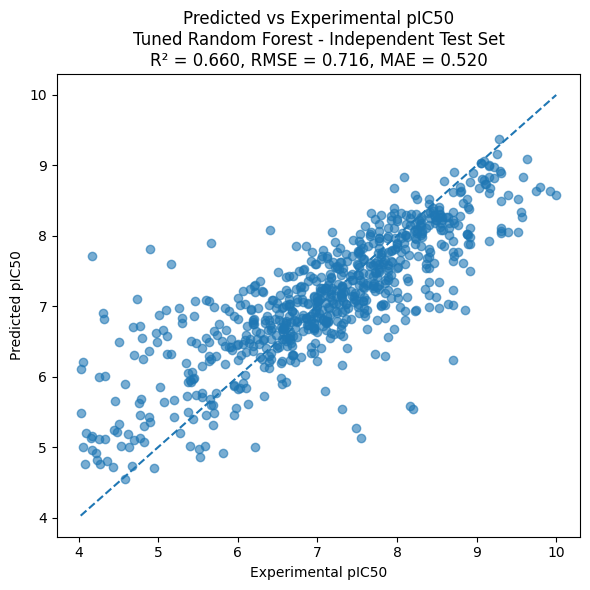

In [52]:
# Final test-set prediction
y_test_pred_final = final_model.predict(X_test)

test_r2_final = r2_score(y_test, y_test_pred_final)
test_mae_final = mean_absolute_error(y_test, y_test_pred_final)
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))

plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred_final, alpha=0.6)

min_val = min(y_test.min(), y_test_pred_final.min())
max_val = max(y_test.max(), y_test_pred_final.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title(
    f"Predicted vs Experimental pIC50\n"
    f"{final_model_name} - Independent Test Set\n"
    f"R² = {test_r2_final:.3f}, RMSE = {test_rmse_final:.3f}, MAE = {test_mae_final:.3f}"
)

plt.tight_layout()

plt.savefig(
    "DPP4_QSAR_final_model_predicted_vs_experimental_test_set.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 12. Residual plot for independent test set**

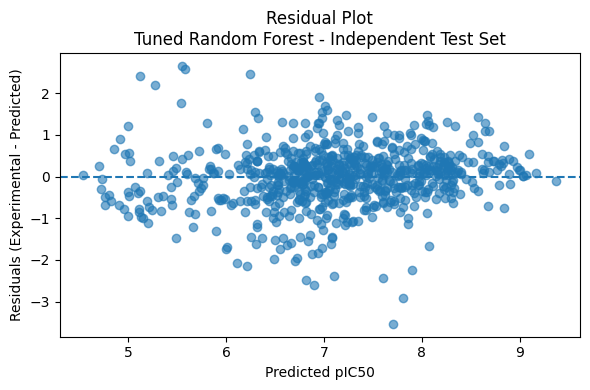

Residual summary:
count    734.000000
mean      -0.014232
std        0.716144
min       -3.535732
25%       -0.380844
50%        0.055004
75%        0.363967
max        2.655641
dtype: float64
DPP4_QSAR_final_model_test_predictions_residuals.csv is available


In [53]:
y_test_pred_final = final_model.predict(X_test)

# Residual = experimental - predicted
residuals_test = y_test - y_test_pred_final

plt.figure(figsize=(6, 4))

plt.scatter(y_test_pred_final, residuals_test, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted pIC50")
plt.ylabel("Residuals (Experimental - Predicted)")
plt.title(f"Residual Plot\n{final_model_name} - Independent Test Set")

plt.tight_layout()

plt.savefig(
    "DPP4_QSAR_final_model_residual_plot_test_set.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual summary:")
print(pd.Series(residuals_test).describe())

# Save independent test-set predictions and residuals
test_prediction_df = pd.DataFrame({
    "Index": idx_test,
    "Experimental_pIC50": y_test,
    "Predicted_pIC50": y_test_pred_final,
    "Residual": residuals_test
})

test_prediction_df.to_csv(
    "DPP4_QSAR_final_model_test_predictions_residuals.csv",
    index=False
)

print("DPP4_QSAR_final_model_test_predictions_residuals.csv is available")

**Combined two panels into one figure**

/tmp/ipykernel_11236/1747480101.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


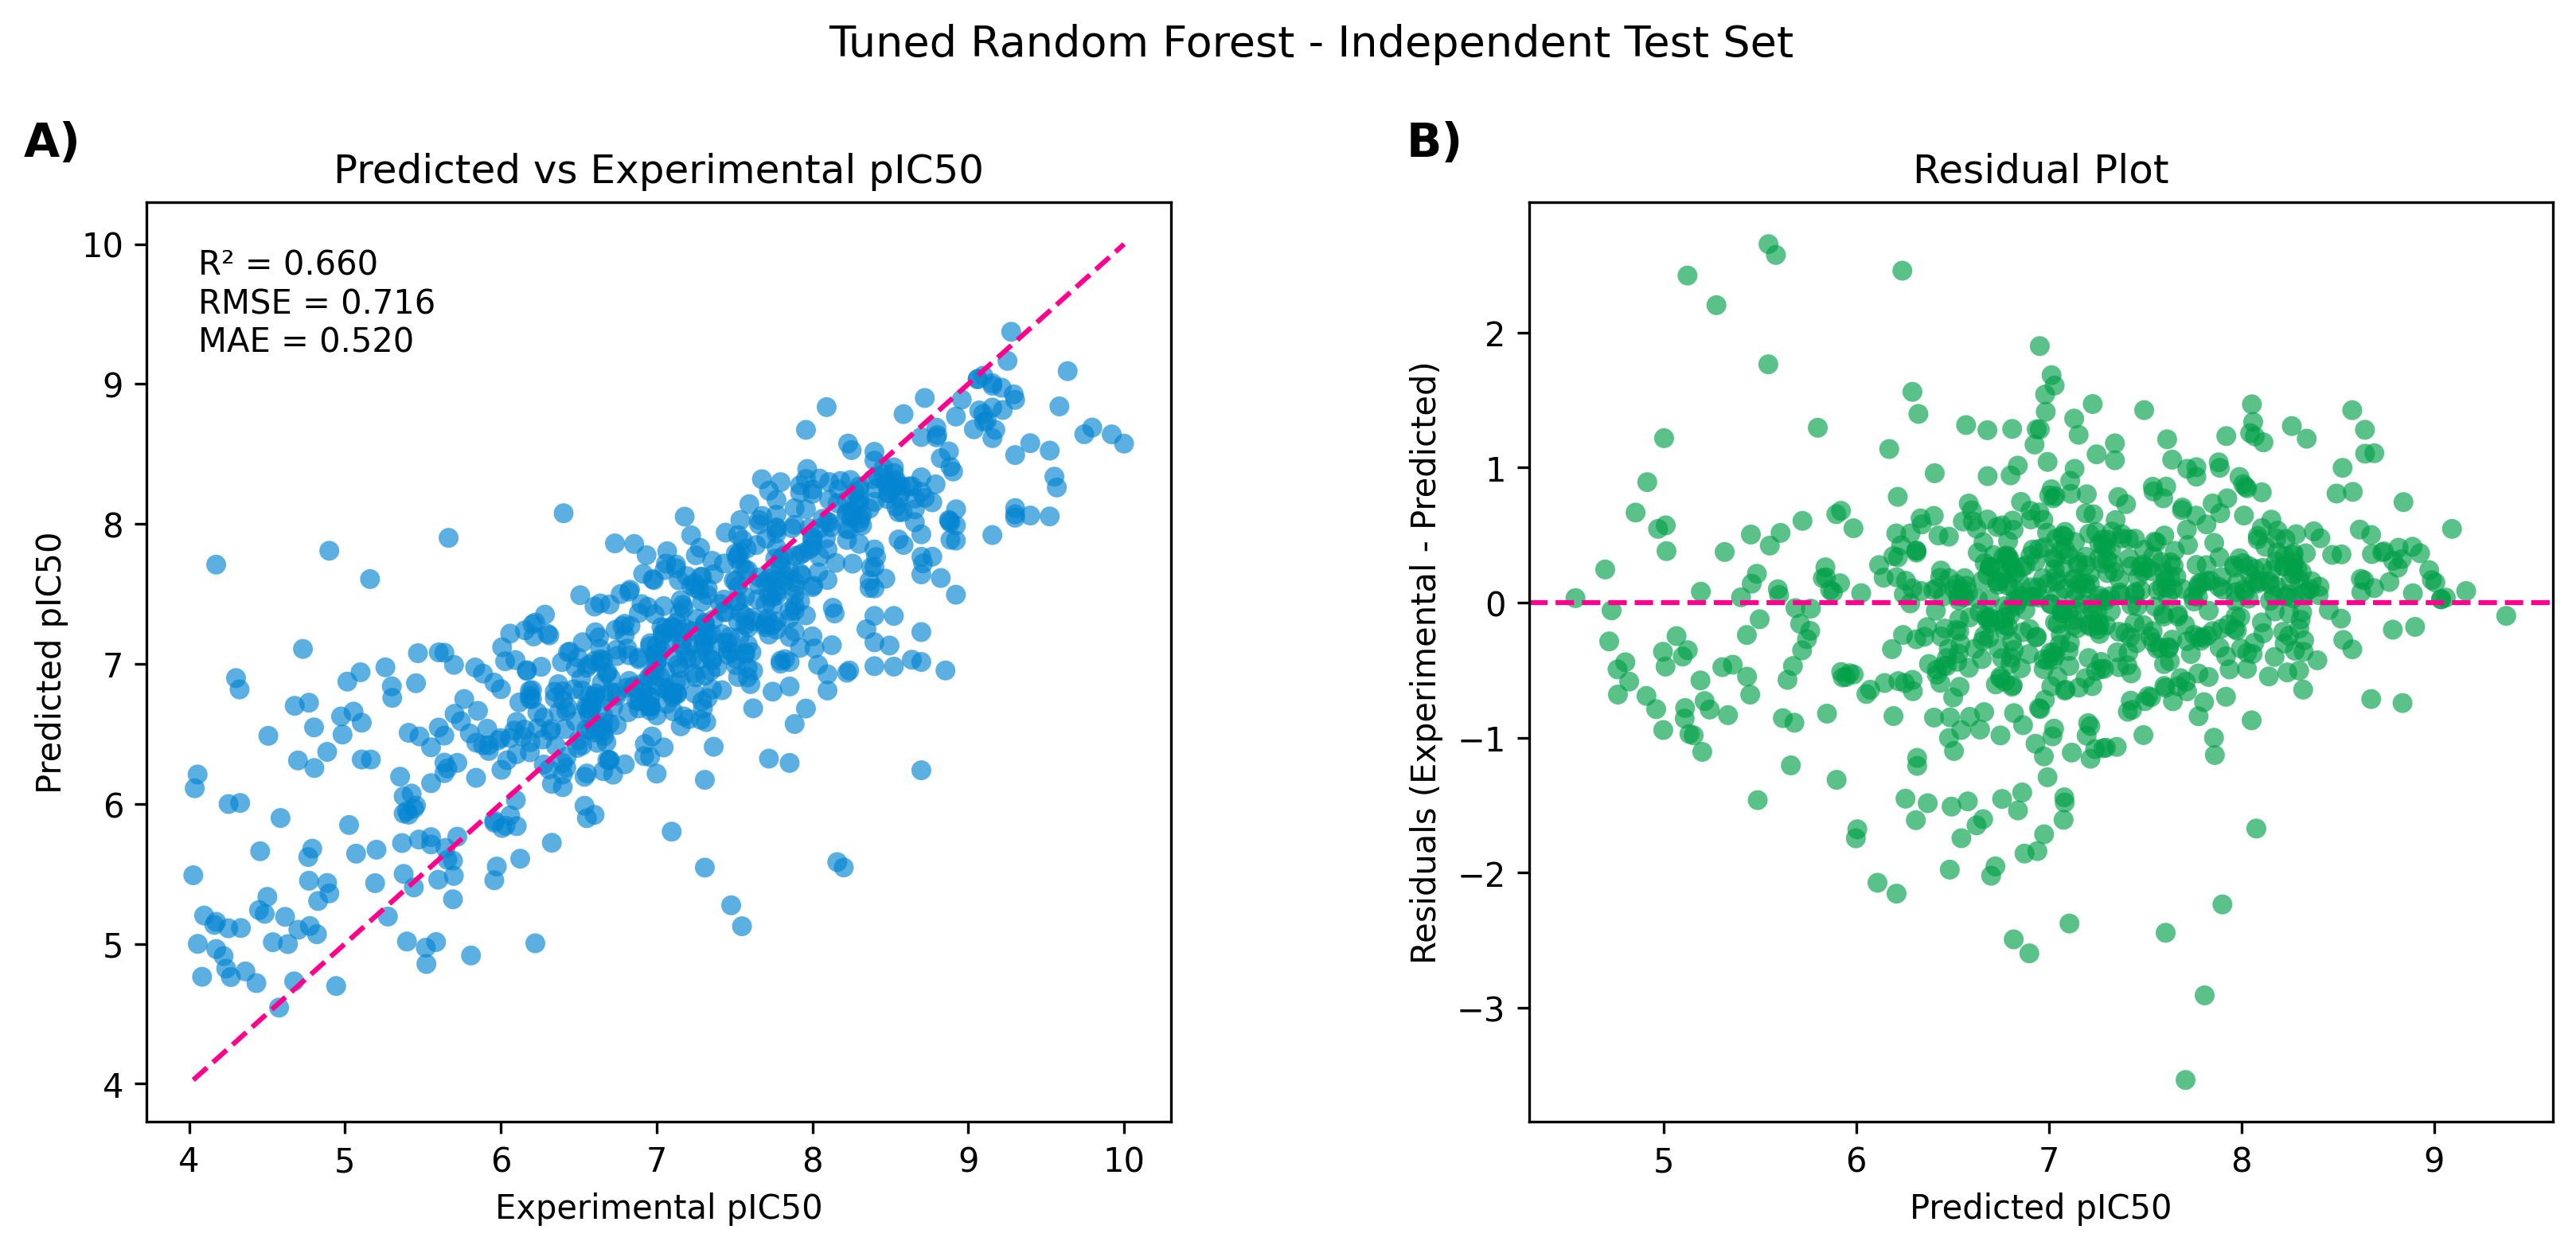

In [60]:
# Final test-set prediction
y_test_pred_final = final_model.predict(X_test)
residuals_test = y_test - y_test_pred_final

# Test-set metrics
test_r2_final = r2_score(y_test, y_test_pred_final)
test_mae_final = mean_absolute_error(y_test, y_test_pred_final)
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))

scatter_color_1 = "xkcd:cerulean"
scatter_color_2 = "xkcd:emerald"
line_color = "xkcd:hot pink"

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    dpi=300,
    gridspec_kw={"wspace": 0.35}
)

# A) Predicted vs experimental plot
ax1 = axes[0]

ax1.scatter(
    y_test,
    y_test_pred_final,
    alpha=0.65,
    color=scatter_color_1,
    edgecolor="none"
)

min_val = min(y_test.min(), y_test_pred_final.min())
max_val = max(y_test.max(), y_test_pred_final.max())

ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color=line_color,
    linewidth=1.5
)

ax1.set_xlabel("Experimental pIC50")
ax1.set_ylabel("Predicted pIC50")
ax1.set_title("Predicted vs Experimental pIC50")

ax1.text(
    0.05, 0.95,
    f"R² = {test_r2_final:.3f}\nRMSE = {test_rmse_final:.3f}\nMAE = {test_mae_final:.3f}",
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top"
)

ax1.text(
    -0.12, 1.05, "A)",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold"
)

# B) Residual plot
ax2 = axes[1]

ax2.scatter(
    y_test_pred_final,
    residuals_test,
    alpha=0.65,
    color=scatter_color_2,
    edgecolor="none"
)

ax2.axhline(
    0,
    linestyle="--",
    color=line_color,
    linewidth=1.5
)

ax2.set_xlabel("Predicted pIC50")
ax2.set_ylabel("Residuals (Experimental - Predicted)")
ax2.set_title("Residual Plot")

ax2.text(
    -0.12, 1.05, "B)",
    transform=ax2.transAxes,
    fontsize=14,
    fontweight="bold"
)

fig.suptitle(f"{final_model_name} - Independent Test Set", fontsize=13, y=1.03)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "DPP4_QSAR_predicted_vs_residual_testset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

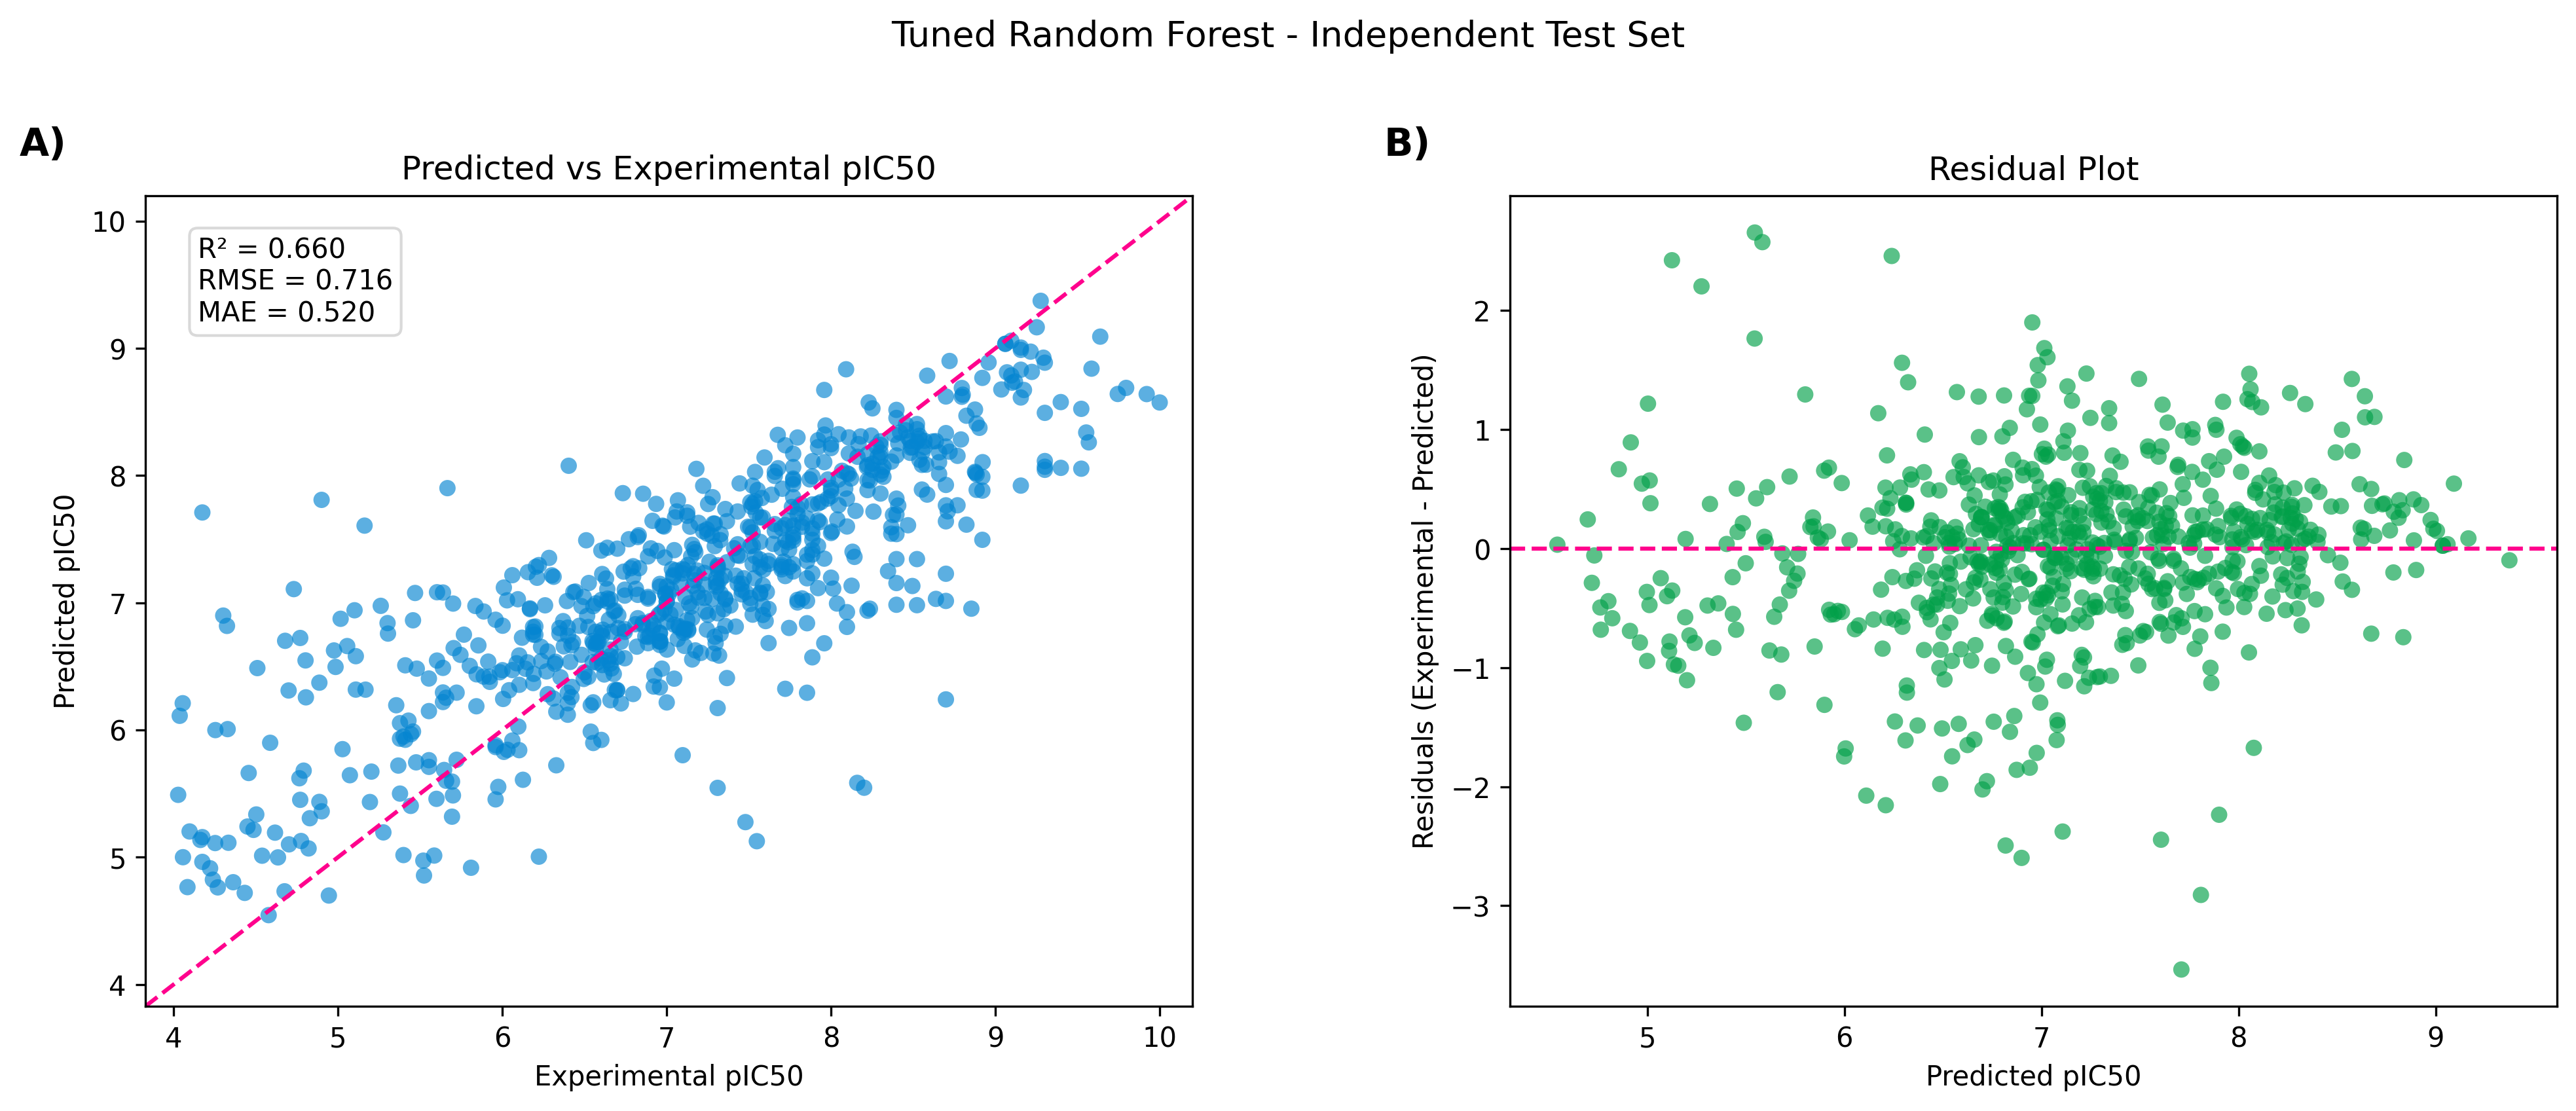

In [65]:
# Final test-set prediction
y_test_pred_final = final_model.predict(X_test)
residuals_test = y_test - y_test_pred_final

# Test-set metrics
test_r2_final = r2_score(y_test, y_test_pred_final)
test_mae_final = mean_absolute_error(y_test, y_test_pred_final)
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))

# Colors
scatter_color_1 = "xkcd:cerulean"
scatter_color_2 = "xkcd:emerald"
line_color = "xkcd:hot pink"

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    dpi=300,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.15}
)


# A) Predicted vs Experimental Plot


ax1 = axes[0]

ax1.scatter(
    y_test,
    y_test_pred_final,
    alpha=0.65,
    color=scatter_color_1,
    edgecolor="none"
)

# Identity line
min_val = min(y_test.min(), y_test_pred_final.min())
max_val = max(y_test.max(), y_test_pred_final.max())

# Add small padding
padding = 0.2
min_plot = min_val - padding
max_plot = max_val + padding

ax1.plot(
    [min_plot, max_plot],
    [min_plot, max_plot],
    linestyle="--",
    color=line_color,
    linewidth=1.5
)

ax1.set_xlim(min_plot, max_plot)
ax1.set_ylim(min_plot, max_plot)

ax1.set_xlabel("Experimental pIC50")
ax1.set_ylabel("Predicted pIC50")
ax1.set_title("Predicted vs Experimental pIC50")

# Metric text box
ax1.text(
    0.05, 0.95,
    f"R² = {test_r2_final:.3f}\nRMSE = {test_rmse_final:.3f}\nMAE = {test_mae_final:.3f}",
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.85
    )
)

# Panel label
ax1.text(
    -0.12, 1.05, "A)",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold"
)


# B) Residual Plot


ax2 = axes[1]

ax2.scatter(
    y_test_pred_final,
    residuals_test,
    alpha=0.65,
    color=scatter_color_2,
    edgecolor="none"
)

ax2.axhline(
    0,
    linestyle="--",
    color=line_color,
    linewidth=1.5
)

ax2.set_xlabel("Predicted pIC50")
ax2.set_ylabel("Residuals (Experimental - Predicted)")
ax2.set_title("Residual Plot")

# Panel label
ax2.text(
    -0.12, 1.05, "B)",
    transform=ax2.transAxes,
    fontsize=14,
    fontweight="bold"
)


# Overall title and save


fig.suptitle(
    f"{final_model_name} - Independent Test Set",
    fontsize=13,
    y=1.10
)

# Save high-resolution figure
plt.savefig(
    "DPP4_QSAR_predicted_vs_residual_testset_ver2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Save the final test-set predictions**

In [51]:
test_prediction_df = df_qsar.iloc[idx_test][
    [
        "molecule_chembl_id",
        "parent_smiles",
        "pIC50_median",
        "activity_class"
    ]
].copy()

test_prediction_df = test_prediction_df.rename(
    columns={"pIC50_median": "Experimental_pIC50"}
)

test_prediction_df["Predicted_pIC50"] = y_test_pred_final

test_prediction_df["Residual"] = (
    test_prediction_df["Experimental_pIC50"] -
    test_prediction_df["Predicted_pIC50"]
)

test_prediction_df["Final_Model"] = final_model_name

output_file = "DPP4_QSAR_final_test_predictions.csv"

test_prediction_df.round(4).to_csv(output_file, index=False)

print(f"{output_file} is available")
display(test_prediction_df.head())

DPP4_QSAR_final_test_predictions.csv is available


,molecule_chembl_id,parent_smiles,Experimental_pIC50,activity_class,Predicted_pIC50,Residual,Final_Model
1404,CHEMBL196881,CS(=O)(=O)c1ccc(-c2nc3c(s2)CCN(C(=O)C[C@H](N)C...,8.853872,High,6.953321,1.900551,Tuned Random Forest
140,CHEMBL3675622,CC#CCn1c(N2CCC[C@@H](N)C2)nc2c1C(=O)N(Cc1nc(C)...,8.886057,High,7.887226,0.998831,Tuned Random Forest
3354,CHEMBL3735843,N[C@H]1C[C@@H](N2Cc3[nH]nc(S(=O)(=O)c4ccccc4)c...,9.397940,High,8.577452,0.820488,Tuned Random Forest
3141,CHEMBL355051,N[C@H](C(=O)N1CCCC1)[C@H]1CCC[C@H](O)C1,6.537602,Moderate,6.193338,0.344264,Tuned Random Forest
3126,CHEMBL279944,N[C@H](C(=O)N1CCC(F)(F)C1)[C@H]1CC[C@H](NC(=O)...,7.568636,High,7.071594,0.497043,Tuned Random Forest
